<a href="https://colab.research.google.com/github/true-cpu/2001230346_HoangTuanKiet_ThucHanhDeepLearning/blob/main/Buoi4_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# List the contents of the newly extracted directory
!ls -R "{zip_extraction_dir}"

/content/extracted_zip_data:
test  train

/content/extracted_zip_data/test:
test

/content/extracted_zip_data/test/test:
false  true

/content/extracted_zip_data/test/test/false:
100.png  157.png  212.png  269.png  324.png  380.png  436.png  492.png	548.png
101.png  158.png  213.png  26.png   325.png  381.png  437.png  493.png	549.png
102.png  159.png  214.png  270.png  326.png  382.png  438.png  494.png	54.png
103.png  15.png   215.png  271.png  327.png  383.png  439.png  495.png	550.png
104.png  160.png  216.png  272.png  328.png  384.png  43.png   496.png	551.png
105.png  161.png  217.png  273.png  329.png  385.png  440.png  497.png	552.png
106.png  162.png  218.png  274.png  32.png   386.png  441.png  498.png	553.png
107.png  163.png  219.png  275.png  330.png  387.png  442.png  499.png	554.png
108.png  164.png  21.png   276.png  331.png  388.png  443.png  49.png	555.png
109.png  165.png  220.png  277.png  332.png  389.png  444.png  4.png	556.png
10.png	 166.png  221.png  278.png  

In [34]:
# Nhập các thư viện cần thiết
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

# Xác định thư mục gốc nơi tệp zip đã được giải nén
base_data_dir = '/content/extracted_zip_data'

# Xác định đường dẫn cho dữ liệu huấn luyện (train) và kiểm tra (test)
train_dir = os.path.join(base_data_dir, 'train', 'train')
test_dir = os.path.join(base_data_dir, 'test', 'test')

print(f"Thư mục dữ liệu huấn luyện: {train_dir}")
print(f"Thư mục dữ liệu kiểm tra: {test_dir}")

# Kiểm tra xem các thư mục có tồn tại không
if not os.path.exists(train_dir):
    print(f"Lỗi: Không tìm thấy thư mục huấn luyện tại {train_dir}")
if not os.path.exists(test_dir):
    print(f"Lỗi: Không tìm thấy thư mục kiểm tra tại {test_dir}")

Thư mục dữ liệu huấn luyện: /content/extracted_zip_data/train/train
Thư mục dữ liệu kiểm tra: /content/extracted_zip_data/test/test


### Bước 2: Chuẩn bị dữ liệu hình ảnh
Chúng ta sử dụng `ImageDataGenerator` để xử lý ảnh.
*   **Chuẩn hóa:** Đưa giá trị các điểm ảnh về khoảng 0-1 để máy tính học nhanh hơn.
*   **Tăng cường dữ liệu (Augmentation):** Tự động xoay, lật, phóng to ảnh để mô hình làm quen với nhiều góc độ khác nhau, giúp nó nhận diện thông minh hơn.

In [35]:
# Cấu hình kích thước hình ảnh
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# Tạo các bộ tạo dữ liệu (Data Generators)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Đọc dữ liệu từ thư mục
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 4438 images belonging to 2 classes.
Found 1114 images belonging to 2 classes.


In [36]:
# Định nghĩa cấu trúc mô hình CNN cơ bản
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

### Bước 3: Huấn luyện mô hình cơ bản
Ở bước này, máy tính sẽ bắt đầu xem các hình ảnh trong thư mục huấn luyện và tự rút ra các đặc điểm để phân biệt giữa 'true' (bị bệnh) và 'false' (không bị bệnh).

In [32]:
# Huấn luyện mô hình
EPOCHS = 10
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)
print("\nHuấn luyện mô hình cơ bản hoàn tất.")

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.5079 - loss: 0.7096 - val_accuracy: 0.5165 - val_loss: 0.6923
Epoch 2/10
  1/138 ━━━━━━━━━━━━━━━━━━━━ 4:54 2s/step - accuracy: 0.5000 - loss: 0.6957

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.5000 - loss: 0.6957 - val_accuracy: 0.5211 - val_loss: 0.6925
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.5111 - loss: 0.6933 - val_accuracy: 0.5349 - val_loss: 0.6916
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.6250 - loss: 0.6813 - val_accuracy: 0.5450 - val_loss: 0.6913
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 242s 2s/step - accuracy: 0.5241 - loss: 0.6920 - val_accuracy: 0.5414 - val_loss: 0.6896
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - accuracy: 0.4688 - loss: 0.6781 - val_accuracy: 0.5414 - val_loss: 0.6892
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.5250 - loss: 0.6928 - val_accuracy: 0.5349 - val_loss: 0.6903
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - accuracy: 0.5938 - loss: 0.6962 - val_accuracy: 0.5312 - val_loss: 0.6909
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.5331 - loss: 0.6916 - val_accurac

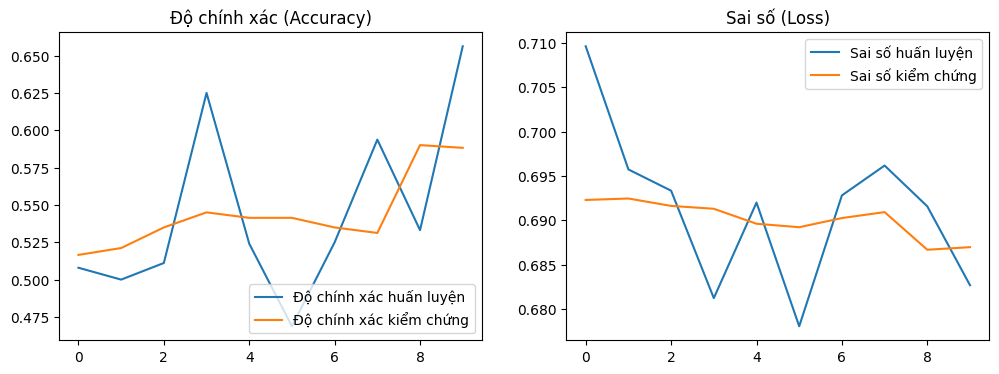

In [37]:
# Vẽ biểu đồ kết quả
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Độ chính xác huấn luyện')
plt.plot(history.history['val_accuracy'], label='Độ chính xác kiểm chứng')
plt.title('Độ chính xác')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Sai số huấn luyện')
plt.plot(history.history['val_loss'], label='Sai số kiểm chứng')
plt.title('Sai số')
plt.legend()
plt.show()

### Bước 4: Cải tiến với Transfer Learning (MobileNetV2)
Sử dụng một mô hình đã được huấn luyện sẵn để tăng độ chính xác.

In [38]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Tải mô hình tiền huấn luyện
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), include_top=False, weights='imagenet')
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_transfer = Model(inputs=base_model.input, outputs=predictions)
model_transfer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print("\nCài đặt mô hình Transfer Learning hoàn tất.")

/tmp/ipykernel_9068/1974673174.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 75, 75,    │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 75, 75,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 75, 75,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 75, 75,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 75, 75,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 75, 75,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 77, 77,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 38, 38,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 38, 38,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 38, 38,    │      2,304 │ block_1_depthwis

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Cài đặt mô hình Transfer Learning hoàn tất.


In [39]:
# Huấn luyện mô hình Transfer Learning
EPOCHS_TRANSFER = 10

history_transfer = model_transfer.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS_TRANSFER,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE
)

print("\nHoàn tất huấn luyện mô hình Transfer Learning.")

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 134s 919ms/step - accuracy: 0.5626 - loss: 0.7224 - val_accuracy: 0.6112 - val_loss: 0.6560
Epoch 2/10
  1/138 ━━━━━━━━━━━━━━━━━━━━ 1:07 491ms/step - accuracy: 0.4062 - loss: 0.7191

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 149ms/step - accuracy: 0.4062 - loss: 0.7191 - val_accuracy: 0.6232 - val_loss: 0.6530
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.5865 - loss: 0.6693 - val_accuracy: 0.5882 - val_loss: 0.6712
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 154ms/step - accuracy: 0.6250 - loss: 0.6382 - val_accuracy: 0.5873 - val_loss: 0.6683
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 162s 891ms/step - accuracy: 0.6046 - loss: 0.6582 - val_accuracy: 0.6507 - val_loss: 0.6339
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 146ms/step - accuracy: 0.4688 - loss: 0.6773 - val_accuracy: 0.6517 - val_loss: 0.6335
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 123s 892ms/step - accuracy: 0.5956 - loss: 0.6590 - val_accuracy: 0.6415 - val_loss: 0.6273
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 41s 292ms/step - accuracy: 0.5625 - loss: 0.6631 - val_accuracy: 0.6379 - val_loss: 0.6278
Epoch 9/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 124s 899ms/step - accuracy: 0.6112 - loss: 0.6462 - va

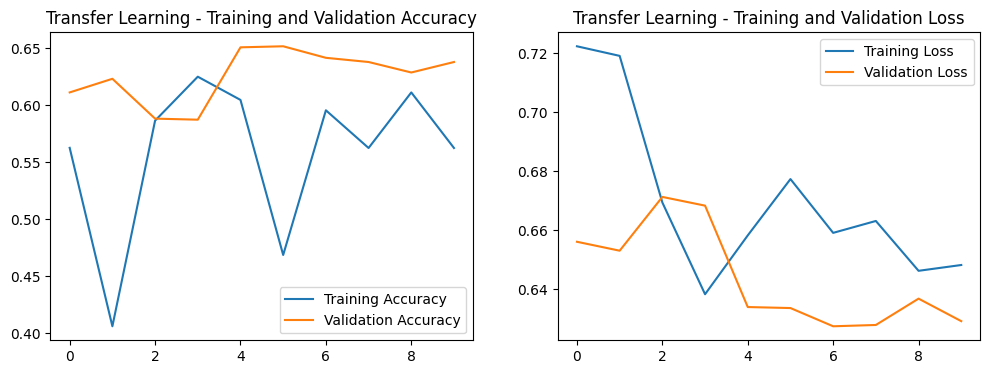

In [40]:
# Vẽ biểu đồ lịch sử huấn luyện cho mô hình Transfer Learning
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_transfer.history['accuracy'], label='Độ chính xác huấn luyện')
plt.plot(history_transfer.history['val_accuracy'], label='Độ chính xác kiểm chứng')
plt.legend(loc='lower right')
plt.title('Transfer Learning - Độ chính xác')

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'], label='Sai số huấn luyện')
plt.plot(history_transfer.history['val_loss'], label='Sai số kiểm chứng')
plt.legend(loc='upper right')
plt.title('Transfer Learning - Sai số')

plt.show()

In [41]:
# Đánh giá mô hình Transfer Learning trên tập dữ liệu kiểm tra
loss_transfer, accuracy_transfer = model_transfer.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)
print(f"\nSai số kiểm tra (Test Loss): {loss_transfer:.4f}")
print(f"Độ chính xác kiểm tra (Test Accuracy): {accuracy_transfer:.4f}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 560ms/step - accuracy: 0.6369 - loss: 0.6317

Transfer Learning Test Loss: 0.6317
Transfer Learning Test Accuracy: 0.6369


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step


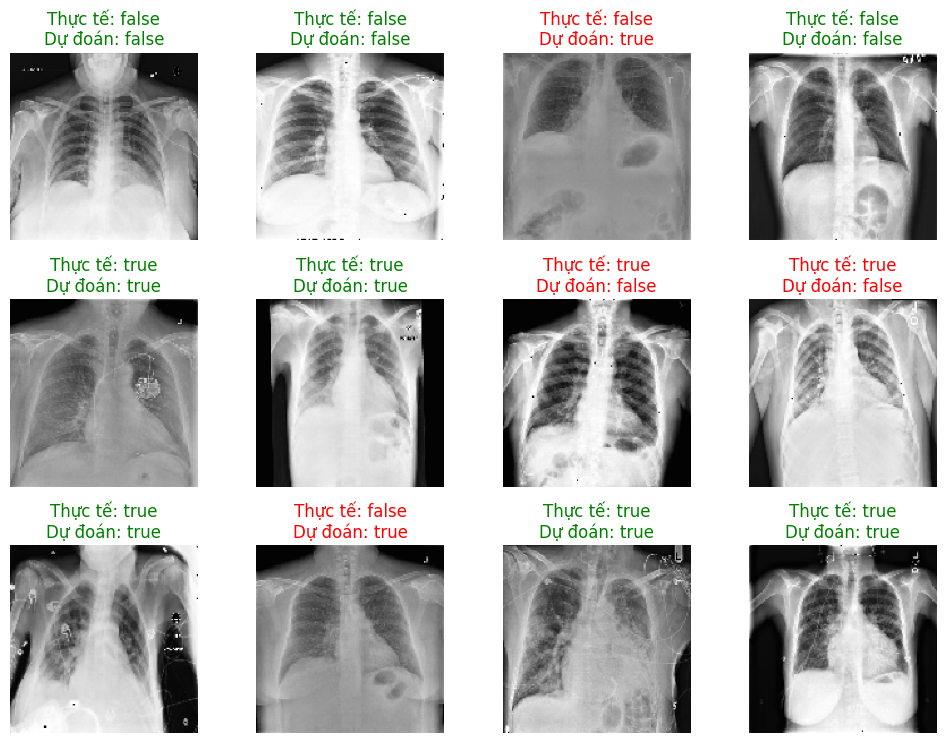

In [44]:
# Dự đoán và hiển thị kết quả mẫu
test_generator.reset()
X_test, y_test = next(test_generator)
predictions = model_transfer.predict(X_test)
predicted_classes = (predictions > 0.5).astype(int)
class_names = list(test_generator.class_indices.keys())

plt.figure(figsize=(10, 10))
for i in range(min(12, len(X_test))):
    plt.subplot(4, 4, i + 1)
    plt.imshow(X_test[i])
    true_label = class_names[int(y_test[i])]
    predicted_label = class_names[predicted_classes[i][0]]
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f"Thực tế: {true_label}\nDự đoán: {predicted_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()